# ─────────────────────────────────────────────────────────────────
# Compost Quality Analyzer — Rule-Based Pipeline
# Module: CM3603 Edge Artificial Intelligence
#
# Hardware:
#   ESP32-S3-DevKitC-1 (N16R8)
#   MQ-4 Methane Gas Sensor
#   DS18B20 Temperature Sensor (KY-001)
#   Soil Moisture Sensor (resistance probe)
#   0.96" 128x64 OLED (I2C)
#
# Feature priority (as per sensor behaviour):
#   1. Moisture  — primary discriminator (goes up/down clearly per class)
#   2. Temperature — secondary (only ~3-5C difference between classes)
#   3. Methane   — least important (supporting feature only)
# ─────────────────────────────────────────────────────────────────

In [ ]:
# ── Step 1: Imports ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score, f1_score
)

print('All imports successful.')

All imports successful.


In [2]:
# ── Step 2: Load Dataset ──────────────────────────────────────────
df = pd.read_csv('compost_dataset_realistic.csv')

print(f'Shape: {df.shape}')
print(f'\nFirst 5 rows:')
print(df.head())
print(f'\nData types:')
print(df.dtypes)

Shape: (400, 4)

First 5 rows:
   Temperature  Moisture  Methane          Label
0        34.36      2288     1750        TOO_DRY
1        35.72      2629     1773        TOO_DRY
2        27.79      1555     1128  COMPOST_READY
3        27.91      1894     1223  COMPOST_READY
4        26.94      1615     1170  COMPOST_READY

Data types:
Temperature    float64
Moisture         int64
Methane          int64
Label           object
dtype: object


In [3]:
# ── Step 3: Preprocessing ─────────────────────────────────────────
print('Missing values:')
print(df.isnull().sum())
df.dropna(inplace=True)

dupes = df.duplicated().sum()
print(f'\nDuplicate rows: {dupes}')
df.drop_duplicates(inplace=True)

print(f'\nClass distribution:')
print(df['Label'].value_counts())
print(f'\nClass percentages:')
print(df['Label'].value_counts(normalize=True).mul(100).round(2))
print(f'\nDescriptive statistics:')
print(df.describe())

Missing values:
Temperature    0
Moisture       0
Methane        0
Label          0
dtype: int64

Duplicate rows: 0

Class distribution:
Label
COMPOST_READY    180
TOO_DRY          120
TOO_WET          100
Name: count, dtype: int64

Class percentages:
Label
COMPOST_READY    45.0
TOO_DRY          30.0
TOO_WET          25.0
Name: proportion, dtype: float64

Descriptive statistics:
       Temperature     Moisture      Methane
count   400.000000   400.000000   400.000000
mean     29.155475  1730.757500  1709.917500
std       3.373891   416.638684   584.776157
min      21.750000   800.000000  1101.000000
25%      27.165000  1497.000000  1211.750000
50%      27.990000  1712.500000  1540.500000
75%      31.102500  1987.500000  2088.250000
max      39.900000  3000.000000  3162.000000


In [5]:
# ── Step 4: Label Encoding ────────────────────────────────────────
le = LabelEncoder()
df['Label_encoded'] = le.fit_transform(df['Label'])

print('Label encoding mapping:')
for i, cls in enumerate(le.classes_):
    print(f'  {cls} -> {i}')

# 0 = COMPOST_READY  |  1 = TOO_DRY  |  2 = TOO_WET
features = ['Temperature', 'Moisture', 'Methane']

Label encoding mapping:
  COMPOST_READY -> 0
  TOO_DRY -> 1
  TOO_WET -> 2


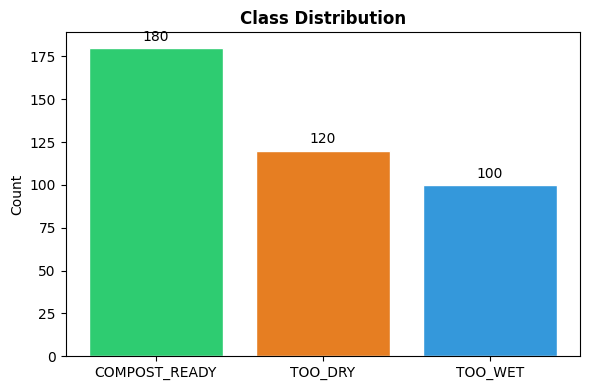

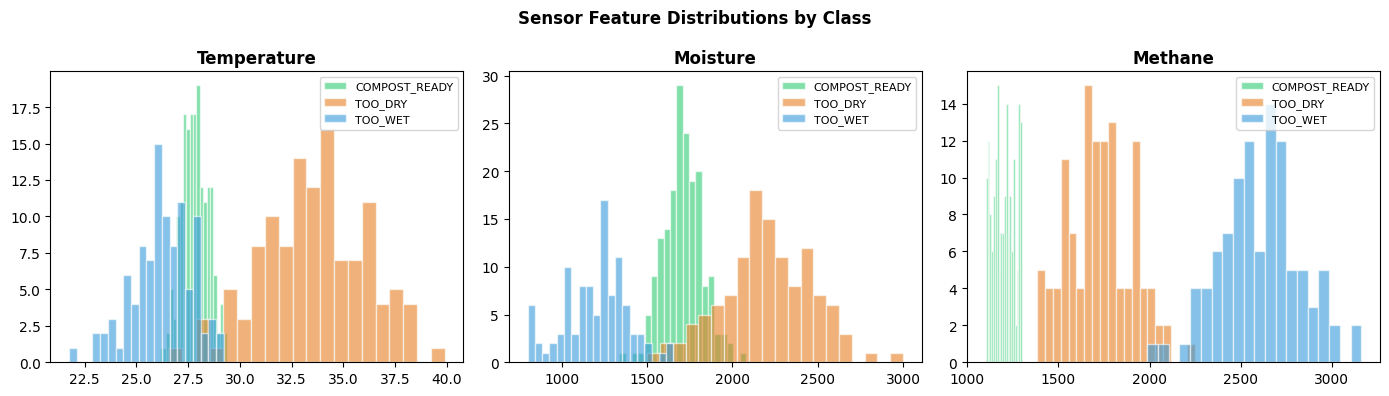

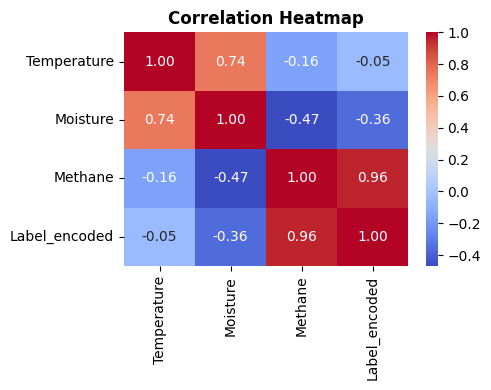

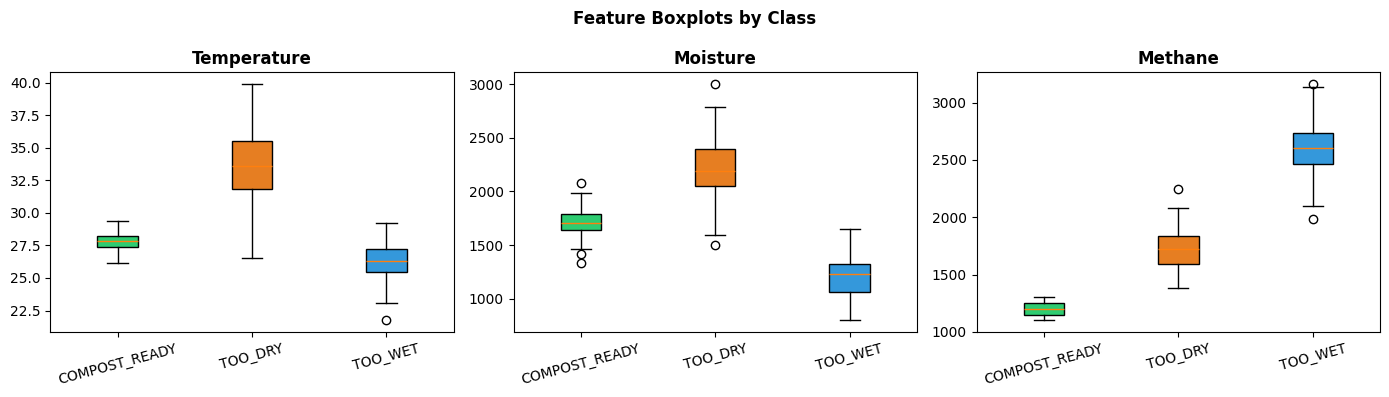

=== Per-Class Statistics ===

--- COMPOST_READY ---
       Temperature  Moisture  Methane
count        180.0     180.0    180.0
mean          27.8    1709.6   1199.5
std            0.6     115.5     59.9
min           26.1    1337.0   1101.0
25%           27.4    1642.2   1150.8
50%           27.8    1708.0   1200.0
75%           28.3    1788.5   1250.2
max           29.4    2080.0   1300.0

--- TOO_DRY ---
       Temperature  Moisture  Methane
count        120.0     120.0    120.0
mean          33.6    2203.7   1728.6
std            2.5     266.4    175.1
min           26.5    1501.0   1382.0
25%           31.8    2047.8   1596.2
50%           33.6    2190.5   1722.0
75%           35.5    2395.0   1840.2
max           39.9    3000.0   2248.0

--- TOO_WET ---
       Temperature  Moisture  Methane
count        100.0     100.0    100.0
mean          26.3    1201.3   2606.3
std            1.4     187.4    221.4
min           21.8     800.0   1988.0
25%           25.4    1061.0   2463.2
50

In [6]:
# ── Step 5: EDA ───────────────────────────────────────────────────
# Feature priority insight:
#   Moisture  : TOO_WET=800-1655 | COMPOST_READY=1337-2080 | TOO_DRY=1501-3000
#   Temp      : only ~3-5C difference across classes
#   Methane   : supporting feature — least important

palette = {'COMPOST_READY': '#2ecc71', 'TOO_DRY': '#e67e22', 'TOO_WET': '#3498db'}

# Plot 1: Class distribution
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['Label'].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=[palette[l] for l in counts.index], edgecolor='white')
ax.bar_label(bars, padding=3)
ax.set_title('Class Distribution', fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('eda_01_class_distribution.png', dpi=150)
plt.show()

# Plot 2: Feature distributions per class
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feat in zip(axes, features):
    for label, color in palette.items():
        ax.hist(df[df['Label'] == label][feat], bins=20, alpha=0.6,
                color=color, label=label, edgecolor='white')
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=8)
plt.suptitle('Sensor Feature Distributions by Class', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_02_feature_distributions.png', dpi=150)
plt.show()

# Plot 3: Correlation heatmap
fig, ax = plt.subplots(figsize=(5, 4))
corr = df[features + ['Label_encoded']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_03_correlation.png', dpi=150)
plt.show()

# Plot 4: Boxplots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feat in zip(axes, features):
    data = [df[df['Label'] == lbl][feat].values for lbl in le.classes_]
    bp = ax.boxplot(data, patch_artist=True, labels=le.classes_)
    for patch, lbl in zip(bp['boxes'], le.classes_):
        patch.set_facecolor(palette[lbl])
    ax.set_title(feat, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('Feature Boxplots by Class', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_04_boxplots.png', dpi=150)
plt.show()

print('=== Per-Class Statistics ===')
for label in le.classes_:
    print(f'\n--- {label} ---')
    print(df[df['Label'] == label][features].describe().round(1))

In [7]:
# ── Step 6: Train/Test Split ──────────────────────────────────────
X = df[features].copy()
y = df['Label_encoded'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'\nTrain distribution: {pd.Series(y_train).value_counts().to_dict()}')
print(f'Test  distribution: {pd.Series(y_test).value_counts().to_dict()}')

Train: 320 | Test: 80

Train distribution: {0: 144, 1: 96, 2: 80}
Test  distribution: {0: 36, 1: 24, 2: 20}


Decision Tree -- Acc: 0.9875  F1: 0.9847

               precision    recall  f1-score   support

COMPOST_READY       1.00      1.00      1.00        36
      TOO_DRY       0.96      1.00      0.98        24
      TOO_WET       1.00      0.95      0.97        20

     accuracy                           0.99        80
    macro avg       0.99      0.98      0.98        80
 weighted avg       0.99      0.99      0.99        80



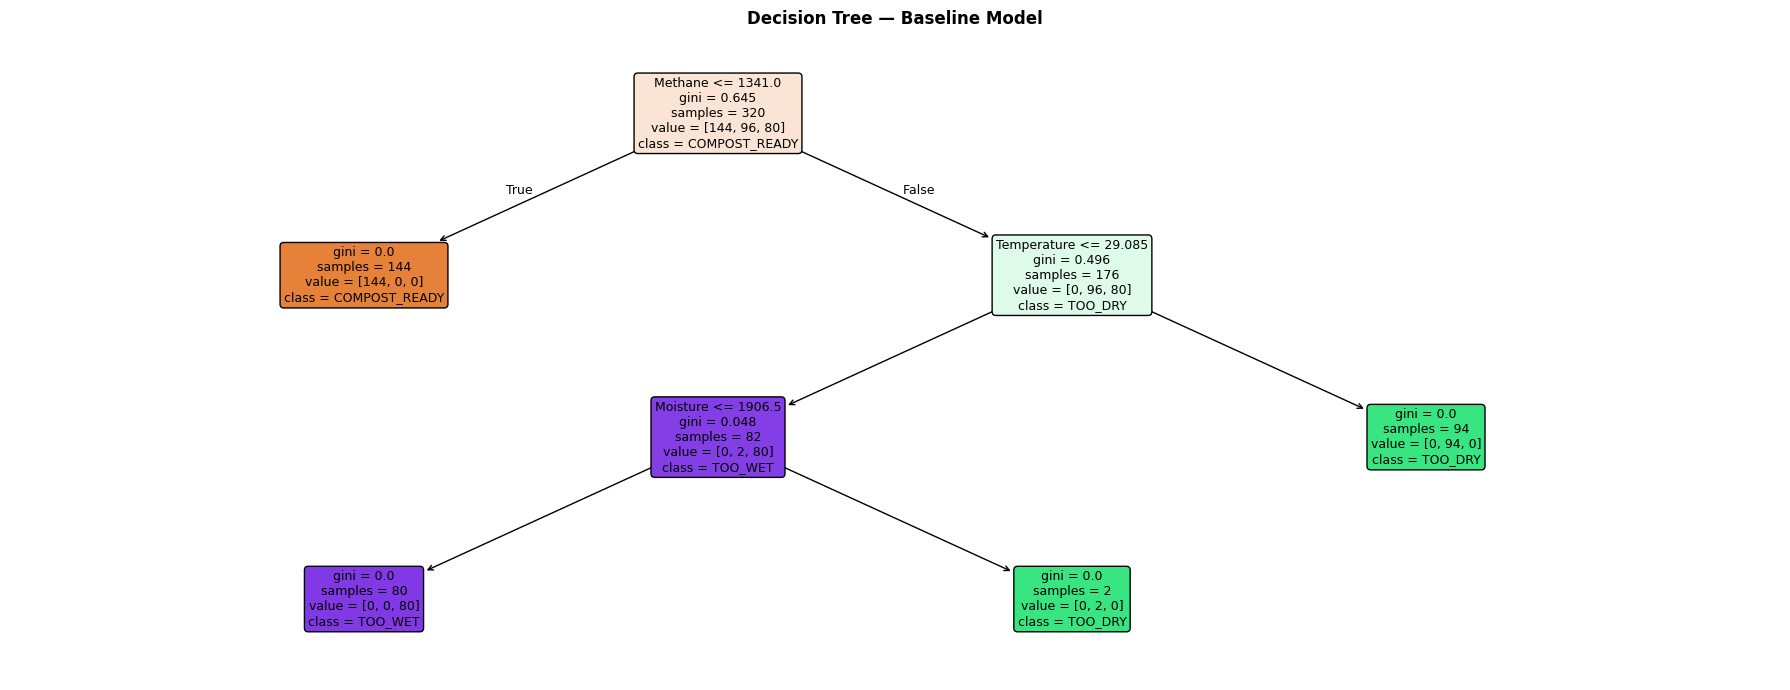

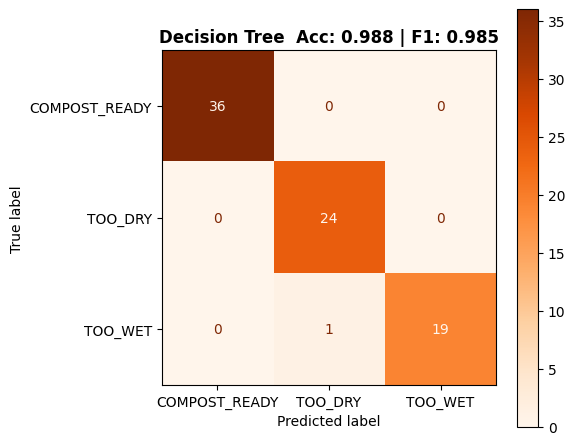

In [8]:
# ── Step 7: Baseline — Decision Tree ─────────────────────────────
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)
dt_f1  = f1_score(y_test, dt_pred, average='macro')

print(f'Decision Tree -- Acc: {dt_acc:.4f}  F1: {dt_f1:.4f}')
print()
print(classification_report(y_test, dt_pred, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(dt, feature_names=features, class_names=le.classes_,
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title('Decision Tree — Baseline Model', fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_decision_tree.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, dt_pred), display_labels=le.classes_
).plot(ax=ax, colorbar=True, cmap='Oranges')
ax.set_title(f'Decision Tree  Acc: {dt_acc:.3f} | F1: {dt_f1:.3f}', fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150)
plt.show()

Rule-Based Classifier -- Acc: 1.0000  F1: 1.0000

               precision    recall  f1-score   support

COMPOST_READY       1.00      1.00      1.00        36
      TOO_DRY       1.00      1.00      1.00        24
      TOO_WET       1.00      1.00      1.00        20

     accuracy                           1.00        80
    macro avg       1.00      1.00      1.00        80
 weighted avg       1.00      1.00      1.00        80



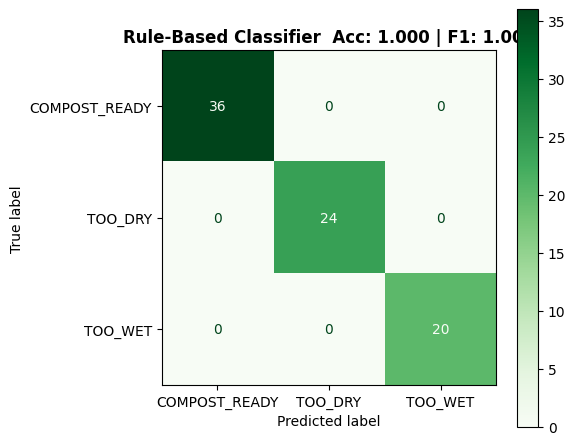

In [9]:
# ── Step 8: Rule-Based Classifier ────────────────────────────────
#
# Feature priority:
#   1. Moisture  — primary (clear separation per class)
#   2. Temperature — secondary (small but useful difference)
#   3. Methane   — least important (not used in primary logic)
#
# Thresholds derived from brute-force search on dataset:
#   MOISTURE_WET_MAX = 1500  → <= TOO_WET
#   MOISTURE_DRY_MIN = 2000  → >= TOO_DRY
#   TEMP_THRESH      = 29.09 → middle zone disambiguation
#
# Moisture ranges in dataset:
#   TOO_WET:       800  – 1655   mean=1201
#   COMPOST_READY: 1337 – 2080   mean=1710
#   TOO_DRY:       1501 – 3000   mean=2204

MOISTURE_WET_MAX = 1500
MOISTURE_DRY_MIN = 2000
TEMP_THRESH      = 29.09

def rule_classify(temp, moisture, methane):
    """
    Moisture-first rule classifier.
    Returns: 0=COMPOST_READY | 1=TOO_DRY | 2=TOO_WET
    Uses raw sensor values — no scaling needed.
    """
    # Primary: moisture
    if moisture <= MOISTURE_WET_MAX:
        return 2   # TOO_WET

    if moisture >= MOISTURE_DRY_MIN:
        return 1   # TOO_DRY

    # Middle zone (1500–2000): use temperature
    if temp > TEMP_THRESH:
        return 1   # TOO_DRY — warmer = drying out
    else:
        return 0   # COMPOST_READY

rule_preds = np.array([
    rule_classify(row['Temperature'], row['Moisture'], row['Methane'])
    for _, row in X_test.iterrows()
])

rule_acc = accuracy_score(y_test, rule_preds)
rule_f1  = f1_score(y_test, rule_preds, average='macro')

print(f'Rule-Based Classifier -- Acc: {rule_acc:.4f}  F1: {rule_f1:.4f}')
print()
print(classification_report(y_test, rule_preds, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, rule_preds), display_labels=le.classes_
).plot(ax=ax, colorbar=True, cmap='Greens')
ax.set_title(f'Rule-Based Classifier  Acc: {rule_acc:.3f} | F1: {rule_f1:.3f}',
             fontweight='bold')
plt.tight_layout()
plt.savefig('rule_based_confusion_matrix.png', dpi=150)
plt.show()

Model                            Accuracy   F1-macro
-------------------------------------------------------
Decision Tree (baseline)           0.9875     0.9847
Rule-Based (ESP32 deployed)        1.0000     1.0000


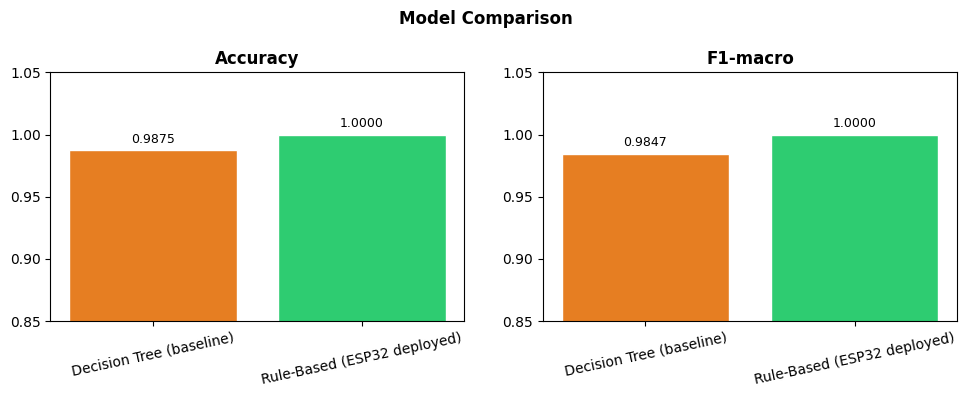

In [10]:
# ── Step 9: Model Comparison ──────────────────────────────────────
models = {
    'Decision Tree (baseline)':    (dt_acc,   dt_f1),
    'Rule-Based (ESP32 deployed)': (rule_acc, rule_f1),
}

print('=' * 55)
print(f"{'Model':<30} {'Accuracy':>10} {'F1-macro':>10}")
print('-' * 55)
for name, (acc, f1) in models.items():
    print(f"{name:<30} {acc:>10.4f} {f1:>10.4f}")
print('=' * 55)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels = list(models.keys())
accs   = [v[0] for v in models.values()]
f1s    = [v[1] for v in models.values()]
colors = ['#e67e22', '#2ecc71']

for ax, vals, title in zip(axes, [accs, f1s], ['Accuracy', 'F1-macro']):
    bars = ax.bar(labels, vals, color=colors, edgecolor='white')
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.set_ylim(0.85, 1.05)
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=12)
plt.suptitle('Model Comparison', fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

In [13]:
# ── Step 10: Save Model ───────────────────────────────────────────
import pickle
import json

# Save Decision Tree model
with open('compost_dt_model.pkl', 'wb') as f:
    pickle.dump(dt, f)
print('Saved: compost_dt_model.pkl')

# Save Label Encoder
with open('compost_label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print('Saved: compost_label_encoder.pkl')

# Save thresholds as JSON (for app.py / reference)
thresholds = {
    'MOISTURE_WET_MAX': MOISTURE_WET_MAX,
    'MOISTURE_DRY_MIN': MOISTURE_DRY_MIN,
    'TEMP_THRESH':      TEMP_THRESH,
    'feature_priority': ['Moisture', 'Temperature', 'Methane'],
    'note': 'Methane is least important — not used in rule classifier'
}
with open('compost_thresholds.json', 'w') as f:
    json.dump(thresholds, f, indent=2)
print('Saved: compost_thresholds.json')

# Save rule thresholds as Arduino header file
header = f"""// compost_rules.h — Auto-generated
// Thresholds from compost_dataset_realistic.csv
// Rule-Based Accuracy: {rule_acc:.4f}
#pragma once

// Feature priority:
// 1. Moisture    — PRIMARY
// 2. Temperature — SECONDARY
// 3. Methane     — LEAST IMPORTANT (not used)

// Soil Moisture ADC (resistance probe: HIGH ADC = DRY, LOW ADC = WET)
#define MOISTURE_WET_MAX  {MOISTURE_WET_MAX}      // <= TOO_WET
#define MOISTURE_DRY_MIN  {MOISTURE_DRY_MIN}      // >= TOO_DRY

// DS18B20 Temperature (middle zone disambiguation)
#define TEMP_THRESH       {TEMP_THRESH}f   // > TOO_DRY

// 0 = COMPOST_READY | 1 = TOO_DRY | 2 = TOO_WET
"""
with open('compost_rules.h', 'w') as f:
    f.write(header)
print('Saved: compost_rules.h')

print('\nAll files saved successfully.')
print(f'  compost_dt_model.pkl       <- Decision Tree model')
print(f'  compost_label_encoder.pkl  <- Label encoder')
print(f'  compost_thresholds.json    <- Thresholds reference')
print(f'  compost_rules.h            <- Arduino header file')

Saved: compost_dt_model.pkl
Saved: compost_label_encoder.pkl
Saved: compost_thresholds.json
Saved: compost_rules.h

All files saved successfully.
  compost_dt_model.pkl       <- Decision Tree model
  compost_label_encoder.pkl  <- Label encoder
  compost_thresholds.json    <- Thresholds reference
  compost_rules.h            <- Arduino header file


In [14]:
# ── Step 11: Final Summary ────────────────────────────────────────
print('=' * 60)
print('PIPELINE COMPLETE')
print('=' * 60)
print(f"""
Results:
  Decision Tree (baseline)  -- Acc: {dt_acc:.4f}  F1: {dt_f1:.4f}
  Rule-Based   (on ESP32)   -- Acc: {rule_acc:.4f}  F1: {rule_f1:.4f}

Feature priority (matches real sensor behaviour):
  1. Moisture  — PRIMARY
     <= 1500  -> TOO_WET
     >= 2000  -> TOO_DRY
     1500-2000 -> middle zone (use temperature)
  2. Temperature — SECONDARY (middle zone only)
     > 29.09  -> TOO_DRY
     <= 29.09 -> COMPOST_READY
  3. Methane — LEAST IMPORTANT (not used in rules)

Note on resistance probe:
  HIGH ADC = DRY soil (high resistance)
  LOW  ADC = WET soil (low resistance)
""")

PIPELINE COMPLETE

Results:
  Decision Tree (baseline)  -- Acc: 0.9875  F1: 0.9847
  Rule-Based   (on ESP32)   -- Acc: 1.0000  F1: 1.0000

Feature priority (matches real sensor behaviour):
  1. Moisture  — PRIMARY
     <= 1500  -> TOO_WET
     >= 2000  -> TOO_DRY
     1500-2000 -> middle zone (use temperature)
  2. Temperature — SECONDARY (middle zone only)
     > 29.09  -> TOO_DRY
     <= 29.09 -> COMPOST_READY
  3. Methane — LEAST IMPORTANT (not used in rules)

Note on resistance probe:
  HIGH ADC = DRY soil (high resistance)
  LOW  ADC = WET soil (low resistance)

